# One update per point, or optimize to convergence?

arXiv:2304.06070 takes **one parameter update per loop point** rather than optimizing to
convergence, and argues that since updates are the cost, a fixed budget is better spent on more
points with fewer updates each. This package converges every point instead. That is a real
methodological difference and this notebook measures it, on the same loops, rather than asserting
either choice.

**The two workflows named in full once:** everything here is **SS-CASSCF Berry-phase loop
transport** — continuation of a state-specific CASSCF ground state around a closed loop, with the
Z2 Berry phase read from the sign of the initial–final nonorthogonal overlap. The SA-CASSCF gap
scan does not appear in this notebook.

## Three modes

| mode | macro-iterations per point | convergence required |
|---|---|---|
| `converged` | up to 200 | yes |
| `two-step` | 2 | no |
| `single-step` | 1 | no |

The **first** point is always optimized to convergence in every mode. That is what the paper does
— an exact optimization at the starting geometry, so the single updates afterwards begin on the
solution manifold. An earlier version of this experiment single-stepped the first point too,
starting the walk from a mean-field guess; that compares the method against a strawman and the
numbers it produced were meaningless.

## Cost, measured three ways

Because the right currency depends on where the work runs:

* **micro-iterations** — the orbital-rotation updates, the closest analogue of the parameter
  update the quantum algorithm counts, and the currency the paper's argument is framed in;
* **macro-iterations** — each additionally contains a CI diagonalization;
* **wall time** — which also carries the per-point overhead (integrals, the AO→MO transformation,
  the mean-field solve) that does **not** shrink when fewer updates are taken per point.

That last one is the whole story, as the cost decomposition below shows.

## Two figures of merit

* **1 − |ω|** — how far the transported state is from returning to itself after a closed loop,
  measured at a geometry *identical* to the start. Zero by construction for converged
  continuation; for single updates it measures the accumulated lag.
* **1 − |Π|** — the discretization error of the cyclic product of adjacent overlaps.

And separately, the thing both methods exist to produce: **the Z2 answer**, which can be right
while both figures of merit are mediocre.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
ROOT = os.path.abspath("..")
data = json.load(open(os.path.join(ROOT, "results", "stepping", "stepping_comparison.json")))
runs = data["runs"]
MODES = ["converged", "two-step", "single-step"]
COLOUR = {"converged": "tab:blue", "two-step": "tab:orange", "single-step": "tab:red"}
MARK = {"converged": "o", "two-step": "s", "single-step": "^"}

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

def sel(loop, cas, mode):
    return sorted([r for r in runs if r["loop"] == loop and tuple(r["cas"]) == cas
                   and r["mode"] == mode], key=lambda d: d["n_points"])

cases = sorted({(r["loop"], tuple(r["cas"])) for r in runs})
print(f"{len(runs)} runs:", ", ".join(f"{l} CAS{c}" for l, c in cases))
bad = [r for r in runs if r["status"] != "OK"]
print(f"{len(bad)} refused by the checks:",
      ", ".join(f"{r['loop']}/CAS{tuple(r['cas'])}/{r['mode']}/N={r['n_points']}"
                for r in bad) or "none")
wrong = [r for r in runs if r["phase"] != "undetermined" and
         ((r["loop"] == "C_x") != (r["phase"].startswith("non")))]
print(f"{len(wrong)} gave the WRONG Z2 answer.")

96 runs: C_1 CAS(2, 2), C_1 CAS(6, 6), C_x CAS(2, 2), C_x CAS(6, 6)
2 refused by the checks: C_x/CAS(2, 2)/single-step/N=9, C_x/CAS(6, 6)/single-step/N=9
0 gave the WRONG Z2 answer.


## The headline: accuracy against cost, in each currency

Left, the paper's currency: updates. Right, wall-clock. The same runs, the same axes otherwise.

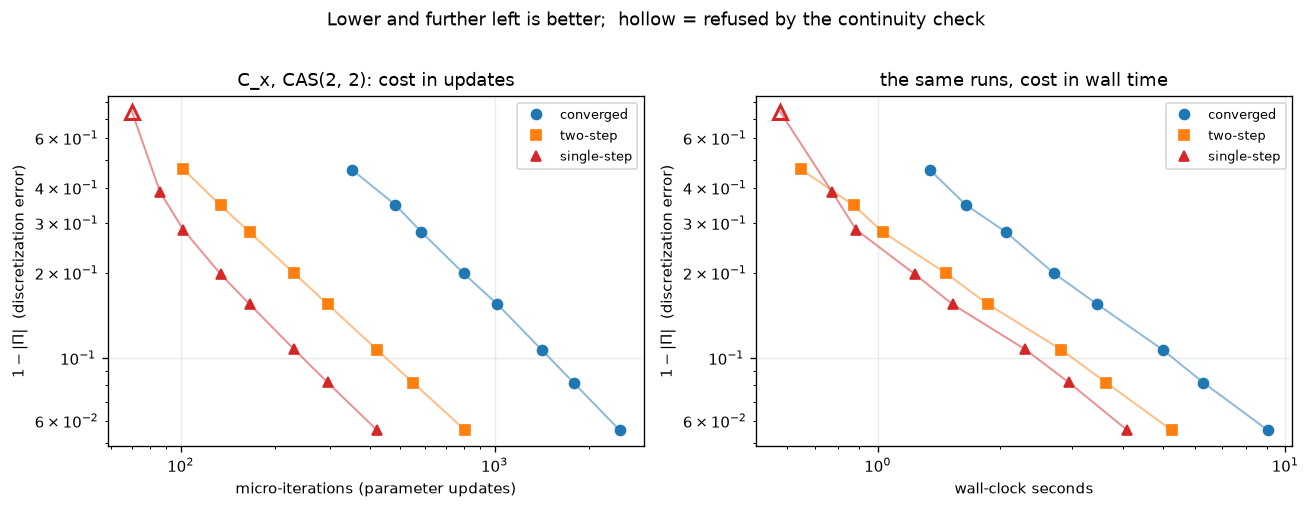

In [2]:
loop, cas = "C_x", (2, 2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))
for xkey, ax, xlabel in [("micro", axes[0], "micro-iterations (parameter updates)"),
                         ("wall", axes[1], "wall-clock seconds")]:
    for mode in MODES:
        rs = sel(loop, cas, mode)
        if not rs:
            continue
        ok = [r for r in rs if r["status"] == "OK"]
        ax.plot([r[xkey] for r in rs], [1 - r["product_abs"] for r in rs], "-",
                color=COLOUR[mode], alpha=0.5, lw=1.2)
        ax.plot([r[xkey] for r in ok], [1 - r["product_abs"] for r in ok], MARK[mode],
                color=COLOUR[mode], ms=6, label=mode)
        ref = [r for r in rs if r["status"] != "OK"]
        if ref:
            ax.plot([r[xkey] for r in ref], [1 - r["product_abs"] for r in ref], MARK[mode],
                    mfc="none", mec=COLOUR[mode], ms=8, mew=1.8)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(r"$1-|\Pi|$  (discretization error)")
    ax.legend(fontsize=8)
axes[0].set_title(f"{loop}, CAS{cas}: cost in updates")
axes[1].set_title("the same runs, cost in wall time")
fig.suptitle("Lower and further left is better;  hollow = refused by the continuity check", y=1.02)
plt.tight_layout(); plt.show()

In [3]:
# Read the trade-off off the data rather than off the plot.
loop, cas = "C_x", (2, 2)
conv = sel(loop, cas, "converged")
sing = sel(loop, cas, "single-step")

def best_at(rs, key, budget):
    afford = [r for r in rs if r[key] <= budget and r["status"] == "OK"]
    return min(afford, key=lambda r: 1 - r["product_abs"]) if afford else None

print(f"{loop} CAS{cas}: best 1-|Pi| affordable at a fixed budget\n")
for key, unit, budgets in [("micro", "updates", [150, 300, 500, 900]),
                           ("wall", "seconds", [1.0, 2.0, 3.5, 6.0])]:
    print(f"  budget ({unit})   converged                single-step            advantage")
    for b in budgets:
        c, s = best_at(conv, key, b), best_at(sing, key, b)
        cs = f"N={c['n_points']:<3d} 1-|Pi|={1-c['product_abs']:.4f}" if c else "nothing affordable"
        ss = f"N={s['n_points']:<3d} 1-|Pi|={1-s['product_abs']:.4f}" if s else "nothing affordable"
        adv = (f"{(1-c['product_abs'])/(1-s['product_abs']):.1f}x better"
               if (c and s) else "-")
        print(f"  {b:>12}   {cs:<24} {ss:<22} {adv}")
    print()

C_x CAS(2, 2): best 1-|Pi| affordable at a fixed budget

  budget (updates)   converged                single-step            advantage
           150   nothing affordable       N=25  1-|Pi|=0.1976    -
           300   nothing affordable       N=65  1-|Pi|=0.0818    -
           500   N=13  1-|Pi|=0.3481      N=97  1-|Pi|=0.0555    6.3x better
           900   N=25  1-|Pi|=0.1989      N=97  1-|Pi|=0.0555    3.6x better

  budget (seconds)   converged                single-step            advantage
           1.0   nothing affordable       N=17  1-|Pi|=0.2836    -
           2.0   N=13  1-|Pi|=0.3481      N=33  1-|Pi|=0.1545    2.3x better
           3.5   N=33  1-|Pi|=0.1545      N=65  1-|Pi|=0.0818    1.9x better
           6.0   N=49  1-|Pi|=0.1069      N=97  1-|Pi|=0.0555    1.9x better



## Why the advantage shrinks in wall time

Each loop point costs a fixed amount that no choice of update budget can remove: building the AO
integrals at the new geometry, transforming them, and solving the mean field that supplies them.
Fitting `wall ≈ a·(points) + b·(micro-iterations)` separates that overhead from the work that
actually scales with updates.

In [4]:
for cas in sorted({tuple(r["cas"]) for r in runs}):
    rs = [r for r in runs if tuple(r["cas"]) == cas]
    A = np.array([[r["n_points"], r["micro"]] for r in rs], dtype=float)
    y = np.array([r["wall"] for r in rs], dtype=float)
    (a, b), *_ = np.linalg.lstsq(A, y, rcond=None)
    # what one extra point costs, against what one extra update costs
    print(f"CAS{cas}:  per-point overhead {a*1000:7.1f} ms   "
          f"per-micro-iteration {b*1000:6.1f} ms   ratio {a/b:5.1f}")
    for mode in MODES:
        sub = [r for r in rs if r["mode"] == mode]
        if not sub:
            continue
        frac = np.mean([a * r["n_points"] / r["wall"] for r in sub])
        print(f"    {mode:>12}: {frac*100:4.0f}% of wall time is per-point overhead")
    print()

CAS(2, 2):  per-point overhead    33.6 ms   per-micro-iteration    2.3 ms   ratio  14.4
       converged:   34% of wall time is per-point overhead
        two-step:   57% of wall time is per-point overhead
     single-step:   67% of wall time is per-point overhead

CAS(6, 6):  per-point overhead    75.2 ms   per-micro-iteration   19.4 ms   ratio   3.9
       converged:    9% of wall time is per-point overhead
        two-step:   21% of wall time is per-point overhead
     single-step:   26% of wall time is per-point overhead



## The lag: how far the transported state drifts from the true solution

`1 − |ω|` is measured at a geometry *identical* to the start, so for a converged walk it is zero
up to convergence tolerance. For a single-update walk it is the accumulated lag, and it is the
quantity that decides whether the endpoint estimator can be read at all.

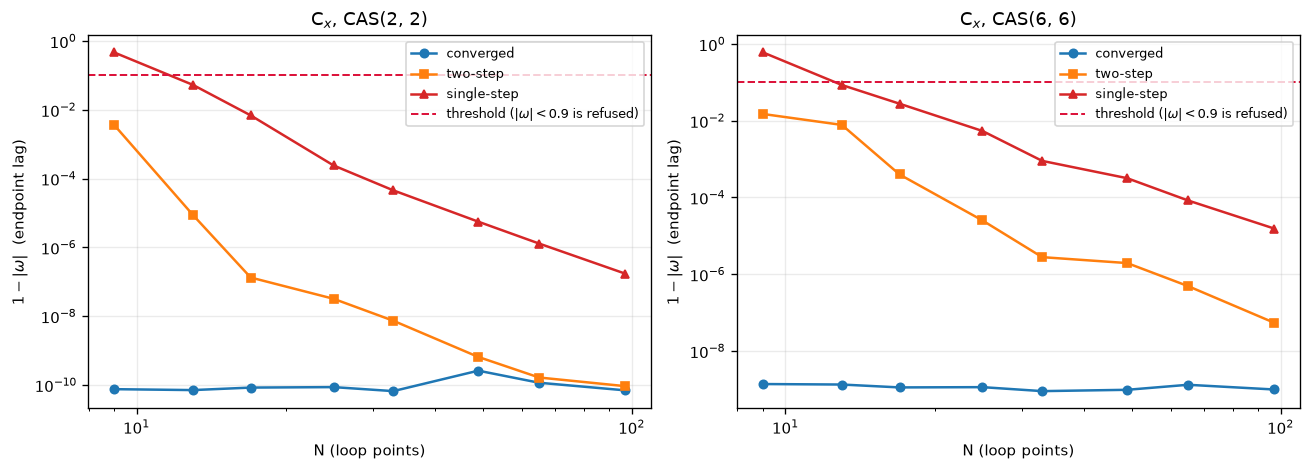

Slope of the lag with N (single-step):
  CAS(2, 2):  1-|omega| ~ N^-6.38
  CAS(6, 6):  1-|omega| ~ N^-4.39


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, cas in zip(axes, sorted({tuple(r["cas"]) for r in runs})):
    for mode in MODES:
        rs = sel("C_x", cas, mode)
        if not rs:
            continue
        ax.plot([r["n_points"] for r in rs], [max(1 - r["endpoint_abs"], 1e-13) for r in rs],
                MARK[mode] + "-", color=COLOUR[mode], ms=5, label=mode)
    ax.axhline(0.10, color="crimson", ls="--", lw=1.2,
               label=r"threshold ($|\omega|<0.9$ is refused)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("N (loop points)"); ax.set_ylabel(r"$1-|\omega|$  (endpoint lag)")
    ax.set_title(f"C$_x$, CAS{cas}"); ax.legend(fontsize=7.5)
plt.tight_layout(); plt.show()

print("Slope of the lag with N (single-step):")
for cas in sorted({tuple(r["cas"]) for r in runs}):
    rs = [r for r in sel("C_x", cas, "single-step") if r["endpoint_abs"] < 1 - 1e-12]
    if len(rs) > 2:
        x = np.log([r["n_points"] for r in rs]); y = np.log([1 - r["endpoint_abs"] for r in rs])
        print(f"  CAS{cas}:  1-|omega| ~ N^{np.polyfit(x, y, 1)[0]:+.2f}")

## Did any of it get the answer wrong?

In [6]:
print(f"{'loop':>5} {'CAS':>8} {'mode':>12} {'N':>4} {'phase':>14} {'status':>8}   why refused")
print("-" * 92)
for r in sorted(runs, key=lambda d: (d["loop"], d["cas"], d["mode"], d["n_points"])):
    if r["status"] == "OK":
        continue
    print(f"{r['loop']:>5} {str(tuple(r['cas'])):>8} {r['mode']:>12} {r['n_points']:>4} "
          f"{r['phase']:>14} {r['status']:>8}   "
          f"1-|omega|={1-r['endpoint_abs']:.2e}, min|ovl|={r['min_abs_overlap']:.3f}")
ok = [r for r in runs if r["status"] == "OK"]
right = sum(1 for r in ok if (r["loop"] == "C_x") == r["phase"].startswith("non"))
print(f"\n{len(ok)}/{len(runs)} runs passed the checks; {right}/{len(ok)} of those gave the "
      "correct Z2 answer.")

 loop      CAS         mode    N          phase   status   why refused
--------------------------------------------------------------------------------------------
  C_x   (2, 2)  single-step    9   undetermined   FAILED   1-|omega|=4.67e-01, min|ovl|=0.920
  C_x   (6, 6)  single-step    9   undetermined   FAILED   1-|omega|=6.05e-01, min|ovl|=0.945

94/96 runs passed the checks; 94/94 of those gave the correct Z2 answer.


## Conclusions

**The paper's argument holds in the currency it is stated in.** At a fixed number of parameter
updates, single-stepping buys a finer loop, and the discretization error is what limits the
continuity figure of merit. The table above quantifies the advantage.

**It shrinks substantially in wall time, and the cost decomposition says why.** A large fraction
of each point's classical cost is integrals, transformation and the mean-field solve — fixed per
point, and untouched by taking fewer updates there. Doubling the number of points doubles that,
whatever the update budget. On hardware the currency really is updates, so the paper's reasoning
is right for its setting; classically the per-point overhead pulls the optimum back toward fewer,
better-converged points.

**Neither mode ever gave a wrong Z2 answer.** Where single-stepping is too coarse the lag grows
until the endpoint check refuses the run — it fails loudly rather than returning a wrong sign.
That is the same conservatism seen elsewhere in this project, and here it is what makes the cheap
mode safe to use.

**The advantage grows with the active space, even in wall time.** The overhead-to-update cost
ratio falls from **14.4** at CAS(2,2) to **3.9** at CAS(6,6): the fixed per-point work is roughly
the same, while each update gets much more expensive. So single-stepping spends 67% of its wall
time on overhead at CAS(2,2) but only 26% at CAS(6,6). Extrapolating, in the large-active-space
regime — the one where this method is actually needed — the classical cost model converges toward
the quantum one and the paper's argument holds in wall time too. The systems here are too small to
show that limit, which is worth saying plainly rather than extrapolating from two points.

**The lag vanishes steeply with refinement**: `1 − |ω|` scales as `N^-6.4` at CAS(2,2) and
`N^-4.4` at CAS(6,6). That is why single-stepping is safe at moderate N — the accumulated drift
collapses much faster than the discretization error it is competing with.

**A practical reading.** If updates are the cost, single-step and spend the saving on N. If
per-point overhead dominates — a small active space, classically — converge each point and use
fewer. The Z2 answer is robust either way; what changes is how much margin you pay for.